In [1]:
# Check directory structure
import os

base_path = "/kaggle/input/mydriverdatausingyolov10"

for folder in os.listdir(base_path):
    print(folder)
    sub = os.path.join(base_path, folder)
    if os.path.isdir(sub):
        print("   ", os.listdir(sub)[:5])


README.dataset.txt
README.roboflow.txt
data.yaml
valid
    ['labels', 'images']
test
    ['labels', 'images']
train
    ['labels', 'images']


In [2]:
# inspect data.yaml file
import yaml

yaml_path = "/kaggle/input/mydriverdatausingyolov10/data.yaml"

with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

data_yaml

{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 8,
 'names': ['Distracted',
  'Drinking',
  'Drowsy',
  'Eating',
  'PhoneUse',
  'SafeDriving',
  'Seatbelt',
  'Smoking'],
 'roboflow': {'workspace': 'driver-monitoring-system-woxvc',
  'project': 'driver-monitoring-system-v0mei',
  'version': 11,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/driver-monitoring-system-woxvc/driver-monitoring-system-v0mei/dataset/11'}}

In [3]:
# count images and labels

from glob import glob

def count_files(path):
    imgs = glob(f"{path}/**/*.jpg", recursive=True) + \
           glob(f"{path}/**/*.png", recursive=True) + \
           glob(f"{path}/**/*.jpeg", recursive=True)

    labels = glob(f"{path}/**/*.txt", recursive=True)
    return len(imgs), len(labels)

for split in ["train", "valid", "test"]:
    img_count, label_count = count_files(f"{base_path}/{split}")
    print(f"{split}: images={img_count}, labels={label_count}")


train: images=29064, labels=29064
valid: images=2053, labels=2053
test: images=1952, labels=1952


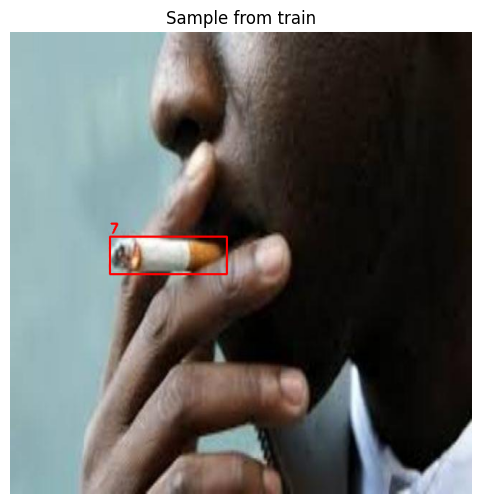

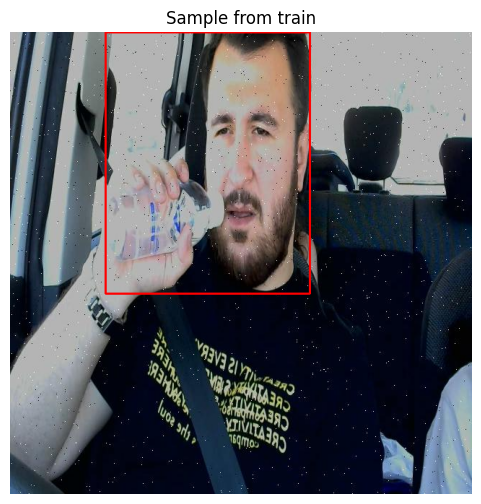

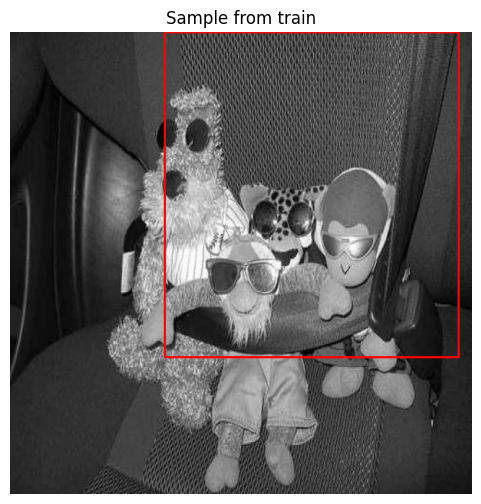

In [5]:
# View some sample images
import cv2
import matplotlib.pyplot as plt
import random

def show_random_images(split="train", n=3):
    img_paths = glob(f"{base_path}/{split}/**/*.jpg", recursive=True)
    img_paths += glob(f"{base_path}/{split}/**/*.png", recursive=True)
    
    for img_path in random.sample(img_paths, n):
        label_path = img_path.replace("images", "labels").rsplit(".",1)[0] + ".txt"
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # draw boxes
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    cls, xc, yc, bw, bh = map(float, line.strip().split())
                    x1 = int((xc - bw/2) * w)
                    y1 = int((yc - bh/2) * h)
                    x2 = int((xc + bw/2) * w)
                    y2 = int((yc + bh/2) * h)
                    cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
                    cv2.putText(img, str(int(cls)), (x1, y1-5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

        plt.figure(figsize=(6,6))
        plt.imshow(img)
        plt.title(f"Sample from {split}")
        plt.axis("off")
        plt.show()

show_random_images("train", n=3)

In [7]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of mkl-fft to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-random to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of mkl-umath to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 99.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [8]:
import warnings
warnings.filterwarnings('ignore')
from ultralytics import YOLO

YOLO('yolov10n.pt')  


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [9]:
from ultralytics import YOLO

model = YOLO("yolov10n.pt")   # small model; faster + good accuracy

model.train(
    data="/kaggle/input/mydriverdatausingyolov10/data.yaml",
    epochs=25,
    imgsz=512,
    batch=16,
    workers=4,
)

Ultralytics 8.3.232 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/mydriverdatausingyolov10/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f48474b3e90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

In [ ]:
model = YOLO("runs/detect/train/weights/best.pt")

model.val(
    data="/kaggle/input/mydriverdatausingyolov10/data.yaml",
    split="test"
)

In [10]:
import os
import shutil
from glob import glob

# --------------------------
#  Find the most recent YOLO training folder
# --------------------------
train_dirs = sorted(glob("runs/detect/train*"), key=os.path.getmtime)
latest_run = train_dirs[-1]  # newest one
print("Latest training folder:", latest_run)

# --------------------------
#  Save best + last weights to Kaggle output
# --------------------------
best_model = f"{latest_run}/weights/best.pt"
last_model = f"{latest_run}/weights/last.pt"

shutil.copy(best_model, "/kaggle/working/best_model.pt")
shutil.copy(last_model, "/kaggle/working/last_model.pt")

print("Saved: best_model.pt and last_model.pt")

# --------------------------
#  Save training plots
# --------------------------
plots = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "labels.jpg"
]

for plot in plots:
    src = f"{latest_run}/{plot}"
    if os.path.exists(src):
        shutil.copy(src, f"/kaggle/working/{plot}")
        print("Saved:", plot)
    else:
        print("Missing:", plot)

# --------------------------
#  Zip the entire run folder (optional)
# --------------------------
zip_path = "/kaggle/working/yolov10_training"
shutil.make_archive(zip_path, 'zip', latest_run)

print("Created zip archive:", zip_path + ".zip")


Latest training folder: runs/detect/train
Saved: best_model.pt and last_model.pt
Saved: results.png
Saved: confusion_matrix.png
Saved: confusion_matrix_normalized.png
Saved: labels.jpg
Created zip archive: /kaggle/working/yolov10_training.zip



WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1952 /kaggle/input/mydriverdatausingyolov10/test/images/-1070-_mp4-25_jpg.rf.5d976d02a89bf3ea1b24518e207891a2.jpg: 512x512 2 SafeDrivings, 2 Seatbelts, 10.2ms
image 2/1952 /kaggle/input/mydriverdatausingyolov10/test/images/-1070-_mp4-26_jpg.rf.7589cbc8dafd378d4cb94c0cea031772.jpg: 512x512 2 SafeDrivings, 1 Seatbelt, 9.2ms
image 3/1952 /kaggle/input/mydriverdatausingyolov10/test/images/-1070-_mp4-31_jpg.rf.3f51bc2e1f5d3bac83e4588f27921652.jpg: 5

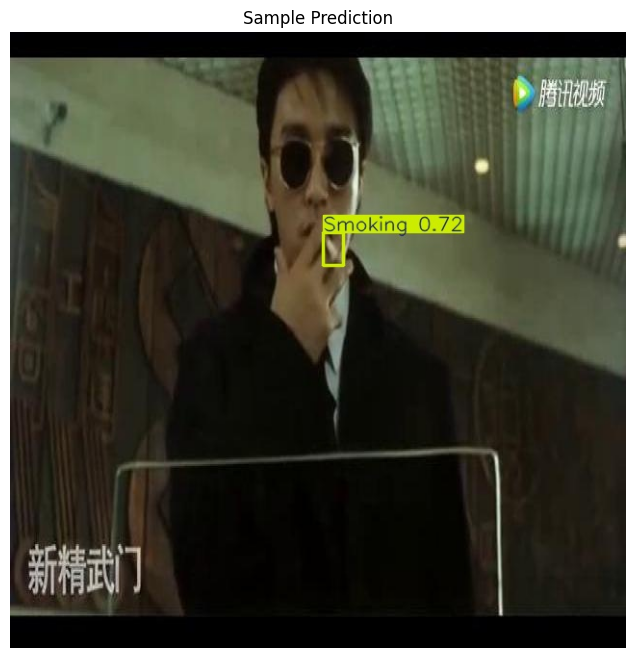

All predictions saved to: /kaggle/working/predictions.zip


In [11]:
# ------------------------------
# FULL YOLOv10 PREDICTION SCRIPT
# ------------------------------

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2, glob, shutil, os

#  Load best model
model = YOLO("/kaggle/working/best_model.pt")  # change if needed


#  Run predictions on all test images
results = model.predict(
    source="/kaggle/input/mydriverdatausingyolov10/test/images",
    conf=0.25,
    save=True,
    imgsz=512
)

print("Prediction folder created!")


#  Find latest prediction folder
pred_folder = sorted(glob.glob("runs/detect/predict*"), key=os.path.getmtime)[-1]
print("Prediction folder:", pred_folder)


#  Display one sample prediction
sample_img = glob.glob(pred_folder + "/*.jpg")[0]

img = cv2.imread(sample_img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title("Sample Prediction")
plt.axis("off")
plt.show()


#  Zip all predictions so Kaggle saves them
zip_path = "/kaggle/working/predictions"
shutil.make_archive(zip_path, "zip", pred_folder)

print("All predictions saved to:", zip_path + ".zip")
